<a href="https://colab.research.google.com/github/tustus1022-ui/esaa/blob/main/ESAA_OB_WEEK1_transcription1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<파이썬 머신러닝 완벽 가이드> 8장 p.488~508 필사하여 깃허브에 업로드

# **08. 텍스트 분석**
- NLP (National Language Processing) : 머신이 인간의 언어를 이해하고 해석하는 데 중점을 두고 발전
- 텍스트 분석 (Text Analytics = 텍스트 마이닝) : 비정형 텍스트에서 의미 있는 정보를 추출하는 것에 중점을 두고 발전


---


- 텍스트 분류 (Text Classification=Text Categorization) : 문서가 특정 분류 또는 카테고리에 속하는 것을 예측하는 기법
- 감성 분석 (Sentiment Analysis) : 텍스트에서 나타나는 감정/판단/믿음/의견/기분 등의 주관적인 요소를 분석하는 기법을 총칭함. 텍스트 분석에서 가장 활발하게 사용되고 있는 분야
- 텍스트 요약 (Summarization) : 텍스트 내에서 중요한 주제나 중심 사상을 추출하는 기법
- 텍스트 군집화와 유사도 측정 : 비슷한 유형의 문서에 대해 군집화를 수행하는 기법

### 01. 텍스트 분석 이해

#### **텍스트 분석 수행 프로세스**
1. 텍스트 사전 준비작업(텍스트 전처리) : : 텍스트를 피처로 만들기 전에 미리 클렌징, 대/소문자 변경, 특수문자 삭제 등의 클렌징 작업, 단어(Word) 등의 토큰화 작업, 의미 없는 단어(Stop word) 제거 작업, 어근 추출(Stemming/Lemmatization) 등의 텍스트 정규화 작업을 수행하는 것을 통칭
2. 피처 백터화/추출 : 사전 준비 작업으로 가공된 텍스트에서 피처를 추출하고 여기에 벡터 값을 할당합니다. 대표적인 방법은 BOW와 Word2Vec이 있으며, Bow는 대표적으로 Count 기반과 TF-IDF 기반 벡터화가 있음
3. ML 모델 수립 및 학습/예측/평가 : 피처 벡터화된 데이터 세트에 ML 모델을 적용해 학습/예측 및 평가를 수행

#### **파이썬 기반의 NLP, 텍스트 분석 패키지**
- NLTK : 파이썬의 가장 대표적인 NLP 패키지
- Gensim : 토픽 모델링 분야에서 가장 두각을 나타내는 패키지
- SpaCy : 뛰어난 성능으로 최근 가장 주목을 받는 패키지

### 02. 텍스트 사전 준비 작업(텍스트 전처리) - 텍스트 정규화

#### **클렌징**
텍스트에서 분석에 오히려 방해가 되는 문자, 기호 등을 사전에 제거 (HTML, XML 태그, 특정 기호 등)

#### **텍스트 토큰화**
문서에서 문장을 분리하는 문장 토큰화, 문장에서 단어를 코튼으로 분리하는 단어 토큰화

**문장 토큰화**

문장의 마침표(.), 개행문자(\n) 등 문장의 마지막을 뜻하는 기호에 따라 분리하는 것이 일반적임. 정규 표현식에 따른 문장 토큰화도 가능함

In [ ]:
ㄹfrom nltk import sent_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

text_sample = 'The Matrix is everywhere its all around us, here even in this room, \
               You can see it out your window or on your television. \
               You feel it when you go to work, or go to church or pay your taxes.'
sentences = sent_tokenize(text=text_sample)
print(type(sentences), len(sentences))
print(sentences)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


<class 'list'> 2
['The Matrix is everywhere its all around us, here even in this room,                You can see it out your window or on your television.', 'You feel it when you go to work, or go to church or pay your taxes.']


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


- sent_tokenize()가 반환하는 것은 각각의 문장으로 구성된 list 객체입니다. 반환된 list 객체가 3개의 문장으로 된 문자열을 가지고 있는 것을 알 수 있다

**단어 토큰화**

기본적으로 공백, 콤마(,), 마침표(.), 개행문자 등으로 단어를 분리하지만, 정규 표현식을 이용해 다양한 유형으로 토큰화를 수행할 수 있다.

In [ ]:
from nltk import word_tokenize

sentence = "The Matrix is everywhere its all around us, here even in this room."
words = word_tokenize(sentence)
print(type(words), len(words))
print(words)

<class 'list'> 15
['The', 'Matrix', 'is', 'everywhere', 'its', 'all', 'around', 'us', ',', 'here', 'even', 'in', 'this', 'room', '.']


In [ ]:
# sent_tokenize와 word_tokenize를 조합해 문서에 대해서 모든 단어를 토큰화
from nltk import word_tokenize, sent_tokenize

# 여러 개의 문장으로 된 입력 데이터를 문장별로 단어 토큰화하게 만드는 함수 생성
def tokenize_text(text):
    # 문장별로 분리 토큰
    sentences = sent_tokenize(text)
    # 분리된 문장별 단어 토큰화
    word_tokens = [word_tokenize(sentence) for sentence in sentences]
    return word_tokens

# 여러 분장에 대해 문장별 단어 토큰화 수행
word_tokens = tokenize_text(text_sample)
print(type(word_tokens),len(word_tokens))
print(word_tokens)

<class 'list'> 2
[['The', 'Matrix', 'is', 'everywhere', 'its', 'all', 'around', 'us', ',', 'here', 'even', 'in', 'this', 'room', ',', 'You', 'can', 'see', 'it', 'out', 'your', 'window', 'or', 'on', 'your', 'television', '.'], ['You', 'feel', 'it', 'when', 'you', 'go', 'to', 'work', ',', 'or', 'go', 'to', 'church', 'or', 'pay', 'your', 'taxes', '.']]


- 3개 문장을 문장별로 먼저 토큰화했으므로 word_tokens 변수는 3개의 리스트 객체를 내포하는 리스
트. 그리고 내포된 개별 리스트 객체는 각각 문장별로 토큰화된 단어를 요소로 가지고 있다.

#### **스톱 워드 제거**
스톱 워드(Stop Word) : 분석에 큰 의미가 없는 단어

<- 이 의미없는 단어를 제거하는 것이 중요한 전처리 작업이다.

언어별로 이러한 스톱 워드가 목록화돼 있습니다. NLTK의 경우 가장 다양한 언어의 스톱 워드를 제공한다. NTLK의 스톱 워드에는 어떤 것이 있는지 확인해보자.

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
print('영어 stop words 개수:', len(nltk.corpus.stopwords.words('english')))
print(nltk.corpus.stopwords.words('english')[:20])

영어 stop words 개수: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


In [ ]:
# 위 예제에서 3개의 문장별로 단어 토큰화해 생성된 word_tokens 리스트에 대해서 스탑 워드를 필터링으로 제거
import nltk

stopwords = nltk.corpus.stopwords.words('english')
all_tokens = []
# 위 예제에서 3개의 문장별로 얻은 word_tokens list에 대해 스톱 워드를 제거하는 반복문
for sentence in word_tokens:
    filtered_words=[]
    # 개별 문장별로 토큰화된 문장 list에 대해 스톱 워드를 제거하는 반복문
    for word in sentence:
        # 소문자로 모두 변환
        word=word.lower()
        # 토큰화된 개별 단어가 스톱 워드의 단어에 포함되지 않으면 word_tokens에 추가
        if word not in stopwords:
            filtered_words.append(word)
        all_tokens.append(filtered_words)

print(all_tokens)

[['matrix', 'everywhere', 'around', 'us', ',', 'even', 'room', ',', 'see', 'window', 'television', '.'], ['matrix', 'everywhere', 'around', 'us', ',', 'even', 'room', ',', 'see', 'window', 'television', '.'], ['matrix', 'everywhere', 'around', 'us', ',', 'even', 'room', ',', 'see', 'window', 'television', '.'], ['matrix', 'everywhere', 'around', 'us', ',', 'even', 'room', ',', 'see', 'window', 'television', '.'], ['matrix', 'everywhere', 'around', 'us', ',', 'even', 'room', ',', 'see', 'window', 'television', '.'], ['matrix', 'everywhere', 'around', 'us', ',', 'even', 'room', ',', 'see', 'window', 'television', '.'], ['matrix', 'everywhere', 'around', 'us', ',', 'even', 'room', ',', 'see', 'window', 'television', '.'], ['matrix', 'everywhere', 'around', 'us', ',', 'even', 'room', ',', 'see', 'window', 'television', '.'], ['matrix', 'everywhere', 'around', 'us', ',', 'even', 'room', ',', 'see', 'window', 'television', '.'], ['matrix', 'everywhere', 'around', 'us', ',', 'even', 'room', '

- is, this와 같은 스톱워드가 필터링을 통해 제거됨

#### **Stemming과 Lemmatization**
Stemming과 Lemmatization은 문법적 또는 의미적으로 변화하는 단어의 원형을 찾는 것

- Stemming : 원형 단어로 변환 시 일반적인 방법을 적용하거나 더 단순화된 방법을 적용해 원래 단어에서 일부 철자가 훼손된 어근 단어를 추출하는 경향이 있음
    - Porter, Lancaster, Snowball Stemmer
- Lemmatization : 품사와 같은 문법적인 요소와 더 의미적인 부분을 감안해 정확한 철자로 된 어근 단어를 찾아줌
    - WordNetLemmatizer

**NTLK에서는 LancasterStemmer()와 같이 필요한 Stemmer 객체를 생성한 뒤 이 객체의 stem('단어') 메서드를 호출하면 원하는 '단어'의 Stemming 이 가능**


In [ ]:
from nltk.stem import LancasterStemmer
stemmer = LancasterStemmer()

print(stemmer.stem('working'),stemmer.stem('works'),stemmer.stem('worked'))
print(stemmer.stem('amusing'),stemmer.stem('amuses'),stemmer.stem('amused'))
print(stemmer.stem('happier'),stemmer.stem('happiest'))
print(stemmer.stem('fancier'),stemmer.stem('fanciest'))

work work work
amus amus amus
happy happiest
fant fanciest


- 형용사인 happy, fancy의 경우도 비교형, 최상급형으로 변형된 단어의 정확한 원형을 찾지 못하고 원형 단어에서 철자가 다른 어근 단어로 인식하는 경우가 발생

In [ ]:
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')

lemma = WordNetLemmatizer()
print(lemma.lemmatize('amusing','v'),lemma.lemmatize('amuses','v'),lemma.lemmatize('amused','v'))
print(lemma.lemmatize('happier','a'),lemma.lemmatize('happiest','a'))
print(lemma.lemmatize('fancier','a'),lemma.lemmatize('fanciest','a'))

[nltk_data] Downloading package wordnet to /root/nltk_data...


amuse amuse amuse
happy happy
fancy fancy


- 앞의 Stemmer보다 정확하게 원형 단어를 추출해줌

### 03. Bag of Words - BOW
Bag of Words 모델 : 문서가 가지는 모든 단어(Words)를 문맥이나 순서를 무시하고 일괄적으로 단어에 대해 빈도 값을 부여해 피처 값을 추출하는 모델

장점
- 쉽고 빠른 구축
- 단순히 단어의 발생 횟수에 기반하고 있지만, 예상보다 문서의 특징을 잘 나타낼 수 있는 모델이기에 전통적으로 여러 분야에서 활용도가 높음

단점
- 문맥 의미(Semantix Context) 반영 부족 : 단어의 순서를 고려하지 않기 때문. 이를 보완하기 위해 n_gram 기법을 활용할 수 있지만 제한적인 부분에 그침
- 희소 행렬 문제(희소성, 희소 행렬) : BOW로 피처 벡터화를 수행하면 희소 행렬 형태의 데이터 세트가 만들어지기 쉽다. 대규모의 칼럼으로 구성된 행렬에서 대부분의 값이 0으로 채워지는 행렬을 희소 행렬(Sparse Matrix)라고 한다. 이와 반대로 대부분의 값이 0이 아닌 의미 있는 값으로 채워져 있는 행렬을 밀집 행렬(Dense Matrix)라고 함. 최소 행렬은 일반적으로 ML 알고리즘의 수행 시간과 예측 성능을 떨어뜨리기 때문에 희소 행렬을 위한 특별한 기법이 마련돼 있음


#### **BOW 피처 벡터화**
특정 의미를 가지는 숫자형 값인 벡터 값으로 텍스트를 변환하는 것

BOW 모델에서 피처 벡터화를 수행한다는 것은 모든 문서에서 모든 단어를 칼럼 형태로 나열하고 각 문서에서 해당 단어의 횟수나 정규화된 빈도를 값으로 부여하는 데이터 세트 모델로 변경하는 것이다.

- 카운트 기반의 벡터화 : 카운트 값이 높을수록 중요한 단어로 인식됨
- TF-IDF (Term Frequency - Inverse Document Frequency) 기반의 벡터화 : 개별 문서에서 자주 나타나는 단어에 높은 가중치를 주되, 모든 문서에서 전반적으로 자주 나타나는 단어에 대해서는 페널티를 주는 방식으로 값을 부여

#### **사이킷런의 Count 및 TF-IDF 벡터화 구현 : CountVectorizer, TfidfVectorizer**
사이킷런의 CountVectorizer 클래스는 카운트 기반의 벡터화를 구현한 클래스. 텍스트 전처리 및 피처 벡터화를 위한 입력 파라미터를 설정해 동작함. fit()과 transform()을 통해 피처 벡터화된 객체를 반환

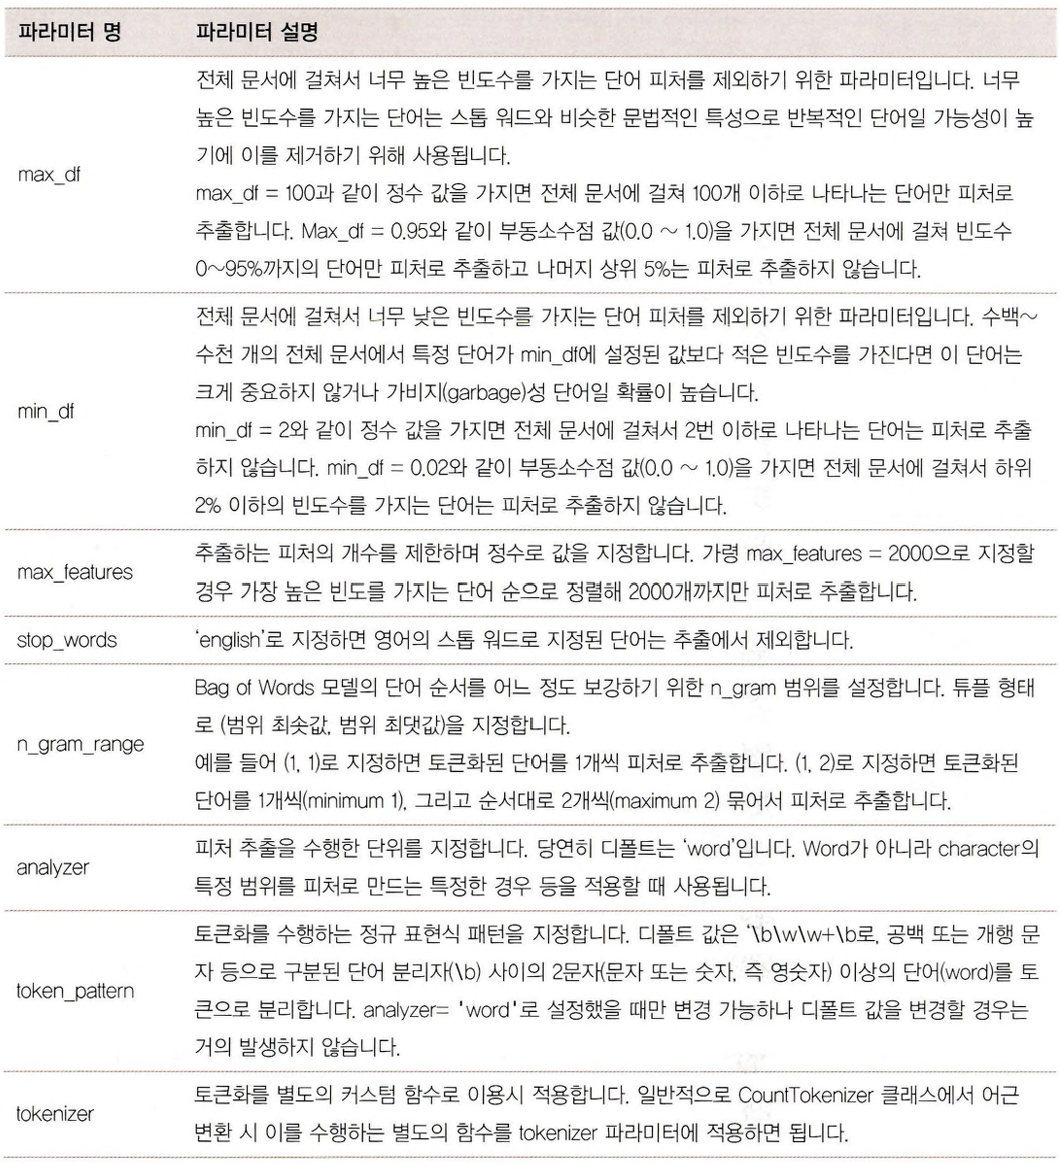

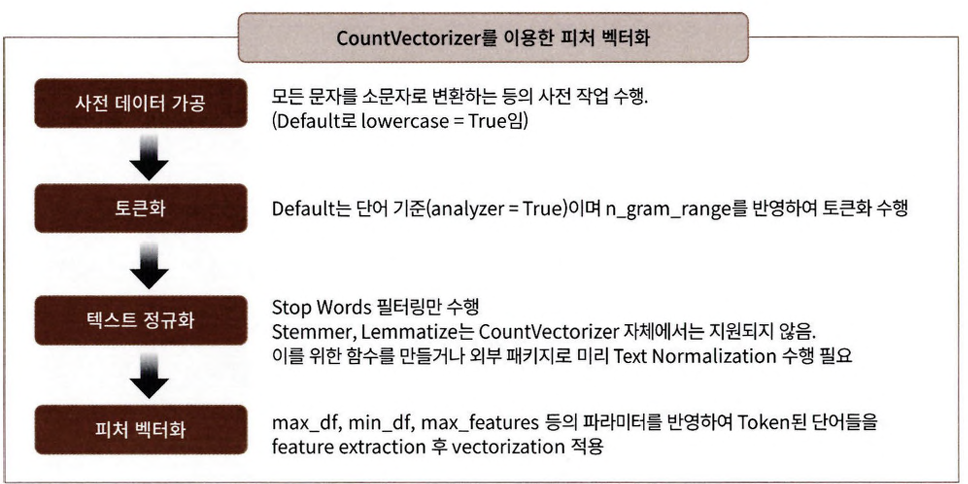

#### **BOW 벡터화를 위한 희소 행렬**
사이킷런의 CountVectorizer/TfidVectorizer를 이용해 텍스트를 피처 단위로 벡터화해 변환하고 CSR 형태의 희소 행렬을 반환함. 난이도 있는 ML 모델을 수립하기 위해서는 희소 행렬이 어떤 형태로 돼 있는지 알아야 함.

희소 행렬을 물리적으로 적은 메모리 공간을 차지할 수 있도록 변환해야 하는데, 대표적인 방법으로 COO 형
식과 CSR 형식이 있다. 일반적으로 큰 희소 행렬을 저장하고 계산을 수행하는 능력이 CSR 형식이 더 뛰어나기 때문에 CSR을 많이 사용함

#### **희소 행렬 - COO 형식**
COO(Coordinate: 좌표) 형식은 0이 아닌 데이터만 별도의 데이터 배열(Array)에 저장하고 그 데이터가 가리키는 행과 열의 위치를 별도의 배열로 저장하는 방식 - 파이썬에서는 주로 Scipy 이용

In [ ]:
import numpy as np

dense = np.array([[3,0,1],[0,2,0]])

In [ ]:
from scipy import sparse

# 0이 아닌 데이터 추출
data = np.array([3,1,2])

# 행 위치와 열 위치를 각각 배열로 생성
row_pos = np.array([0,0,1])
col_pos = np.array([0,2,1])

# sparse 패키지의 coo_matrix를 이용해 COO 형식으로 희소 행렬 생성
sparse_coo = sparse.coo_matrix((data, (row_pos, col_pos)))

- sparse_coo는 COO 형식의 희소 행렬 객체 변수. 이를 toarray() 메서드를 이용해 다시 밀집 형태의 행렬로 출력

In [ ]:
sparse_coo.toarray()

array([[3, 0, 1],
       [0, 2, 0]])

#### **희소 행렬 - CSR 형식**
CSR(Compressed Sparse Row) 형식은 COO 형식이 행과 열의 위치를 나타내기 위해서 반복적인 위치 데이터를 사용해야 하는 문제점을 해결한 방식

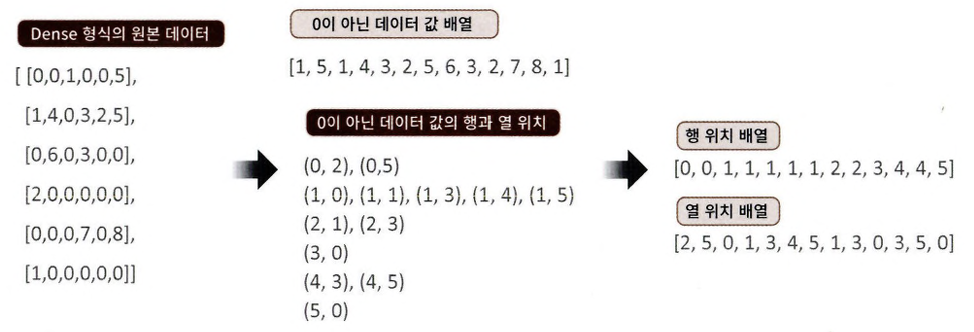

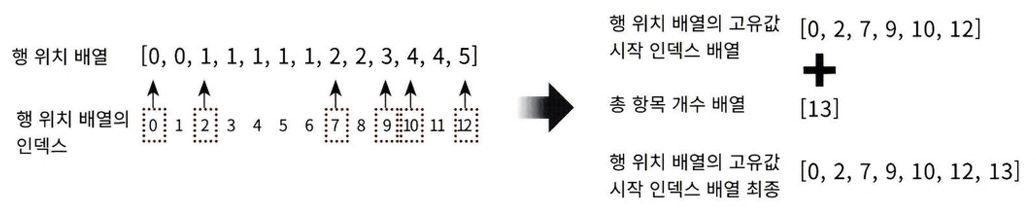

In [ ]:
from scipy import sparse

dense2 = np.array([[0,0,1,0,0,5],
                   [1,4,0,3,2,5],
                   [0,6,0,3,0,0],
                   [2,0,0,0,0,0],
                   [0,0,0,7,0,8],
                   [1,0,0,0,0,0]])

# 0이 아닌 데이터 추출
data2 = np.array([1,5,1,4,3,2,5,6,3,2,7,8,1])

# 행 위치와 열 위치를 각각 array로 생성
row_pos = np.array([0,0,1,1,1,1,1,2,2,3,4,4,5])
col_pos = np.array([2,5,0,1,3,4,5,1,3,0,3,5,0])

# COO 형식으로 변환
sparse_coo = sparse.coo_matrix((data2, (row_pos, col_pos)))

# 행 위치 배열의 고유한 값의 시작 위치 인덱스를 배열로 생성
row_pos_ind = np.array([0,2,7,9,10,12,13])

# CSR 형식으로 변환
sparse_csr = sparse.csr_matrix((data2, col_pos, row_pos_ind))

print('COO 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인')
print(sparse_coo.toarray())
print('CSR 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인')
print(sparse_csr.toarray())

COO 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인
[[0 0 1 0 0 5]
 [1 4 0 3 2 5]
 [0 6 0 3 0 0]
 [2 0 0 0 0 0]
 [0 0 0 7 0 8]
 [1 0 0 0 0 0]]
CSR 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인
[[0 0 1 0 0 5]
 [1 4 0 3 2 5]
 [0 6 0 3 0 0]
 [2 0 0 0 0 0]
 [0 0 0 7 0 8]
 [1 0 0 0 0 0]]


- 실제 사용 시에는 다음과 같이 밀집 행렬을 생성 파라미터로 입력하면 COO나 CSR 희소 행렬로 생성함

In [ ]:
'''
dense3 = np.array([[0,0,1,0,0,5],
                   [1,4,0,3,2,5],
                   [0,6,0,3,0,0],
                   [2,0,0,0,0,0],
                   [0,0,0,7,0,8],
                   [1,0,0,0,0,0]])
coo = sparse.coo_matrix(dense3)
csr = sparse.csr_matirx(dense3)
'''

'\ndense3 = np.array([[0,0,1,0,0,5],\n                   [1,4,0,3,2,5],\n                   [0,6,0,3,0,0],\n                   [2,0,0,0,0,0],\n                   [0,0,0,7,0,8],\n                   [1,0,0,0,0,0]])\ncoo = sparse.coo_matrix(dense3)\ncsr = sparse.csr_matirx(dense3)\n'

- 사이킷런의 CountVectorizer나 TfidfVectorizer 클래스로 변환된 피처 벡터화 행렬은 모두 사이파이의 CSR 형태의 희소 행렬이다.